In [2]:
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import mne
from mne.time_frequency import tfr_morlet

mne.set_log_level('WARNING')

# ─── Paths ───────────────────────────────────────────────────────────────────
ROOT_DIR  = pathlib.Path('/Users/syja/Desktop/Princeton/FirstYear/Courses/2026Spring/NEU502B')
DERIV_DIR = ROOT_DIR / 'data/wordoddball/bids/derivatives/analysis__2/sub-002/ses-01/meg'

SUBJECT   = 'sub-002'
SESSION   = 'ses-01'
TASK      = 'wordoddball'

epo_file = DERIV_DIR / f'{SUBJECT}_{SESSION}_task-{TASK}_proc-clean_epo.fif'
print(f'Epochs file : {epo_file}')
print(f'Exists      : {epo_file.exists()}')

epochs = mne.read_epochs(epo_file, preload=True, verbose=False)
print(epochs)
print(f'Sampling rate : {epochs.info["sfreq"]} Hz')
print(f'Time range    : {epochs.times[0]:+.3f} to {epochs.times[-1]:+.3f} s')


Epochs file : /Users/syja/Desktop/Princeton/FirstYear/Courses/2026Spring/NEU502B/data/wordoddball/bids/derivatives/analysis__2/sub-002/ses-01/meg/sub-002_ses-01_task-wordoddball_proc-clean_epo.fif
Exists      : True
<EpochsFIF | 798 events (all good), -0.2 – 1.2 s (baseline -0.2 – 0 s), ~734.7 MiB, data loaded, with metadata,
 'deviant': 129
 'standard': 669>
Sampling rate : 400.0 Hz
Time range    : -0.200 to +1.200 s


In [4]:
CHANS_OF_INTEREST = ['T5 3D Z', 'T9 34 Z']

# Z channels only
z_picks = [ch for ch in epochs.ch_names if ch.endswith(' Z')]
epochs_z = epochs.copy().pick(z_picks)

# Sanity check — both channels exist
missing = [c for c in CHANS_OF_INTEREST if c not in epochs_z.ch_names]
if missing:
    raise ValueError(f'Missing channel(s) in epochs: {missing}')
print(f'Z channels available : {len(epochs_z.ch_names)}')
print(f'Channels of interest : {CHANS_OF_INTEREST}')


Z channels available : 74
Channels of interest : ['T5 3D Z', 'T9 34 Z']


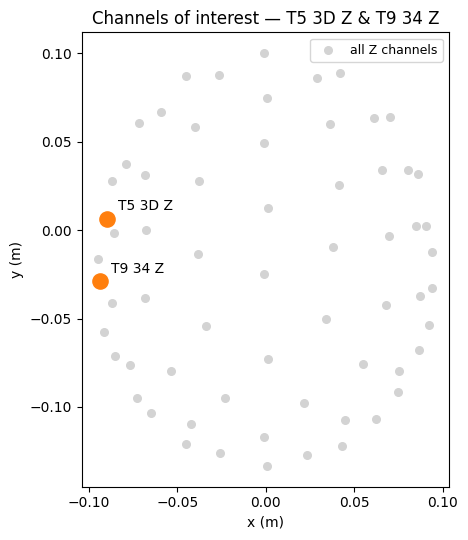

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))

# All Z-channel positions
pos = np.array([epochs_z.info['chs'][i]['loc'][:2]
                for i in range(len(epochs_z.ch_names))])
ax.scatter(pos[:, 0], pos[:, 1], s=30, c='lightgrey', label='all Z channels')

# Highlight our two channels
for ch in CHANS_OF_INTEREST:
    idx = epochs_z.ch_names.index(ch)
    x, y = epochs_z.info['chs'][idx]['loc'][:2]
    ax.scatter(x, y, s=120, c='tab:orange', zorder=3)
    ax.annotate(ch, (x, y), xytext=(8, 6), textcoords='offset points', fontsize=10)

ax.set_aspect('equal')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_title('Channels of interest — T5 3D Z & T9 34 Z')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()


In [8]:
# Find the deviant epochs and the standard epoch immediately before each one.
events_arr = epochs_z.events
event_id   = epochs_z.event_id

# Get the integer codes for standard / deviant
std_code = event_id[[k for k in event_id if 'standard' in k.lower()][0]]
dev_code = event_id[[k for k in event_id if 'deviant'  in k.lower()][0]]
print(f'standard code : {std_code}')
print(f'deviant  code : {dev_code}')

# Find indices of deviant trials in the SELECTION (kept-trial) list
sel_codes = events_arr[:, 2]
dev_idx_in_kept = np.where(sel_codes == dev_code)[0]

# For each deviant, find the previous kept trial — keep only if it's a standard
matched_std_idx = []
matched_dev_idx = []
for di in dev_idx_in_kept:
    if di == 0:
        continue
    if sel_codes[di - 1] == std_code:
        matched_std_idx.append(di - 1)
        matched_dev_idx.append(di)

epochs_std_matched = epochs_z[matched_std_idx]
epochs_dev_matched = epochs_z[matched_dev_idx]

print(f'\nMatched standard trials : {len(epochs_std_matched)}')
print(f'Matched deviant  trials : {len(epochs_dev_matched)}')


standard code : 4
deviant  code : 2

Matched standard trials : 129
Matched deviant  trials : 129


In [11]:
freqs    = np.arange(4, 41, 1)
n_cycles = freqs / 2.0  # constant ~time resolution across freqs

# Standard
_, itc_std = tfr_morlet(
    epochs_std_matched, freqs=freqs, n_cycles=n_cycles,
    use_fft=True, return_itc=True, decim=2, n_jobs=1, verbose=False,
)
# Deviant
_, itc_dev = tfr_morlet(
    epochs_dev_matched, freqs=freqs, n_cycles=n_cycles,
    use_fft=True, return_itc=True, decim=2, n_jobs=1, verbose=False,
)

# Difference (deviant − standard)
itc_diff = itc_dev.copy()
itc_diff.data = itc_dev.data - itc_std.data
itc_diff.comment = 'deviant - context-matched standard'

print(f'ITC tensor shape (per condition) : {itc_std.data.shape}  (chs × freqs × times)')
print(f'Time axis                        : {itc_std.times[0]:+.3f} to {itc_std.times[-1]:+.3f} s')
print(f'Frequency axis                   : {itc_std.freqs[0]} to {itc_std.freqs[-1]} Hz')


ITC tensor shape (per condition) : (61, 37, 281)  (chs × freqs × times)
Time axis                        : -0.200 to +1.200 s
Frequency axis                   : 4.0 to 40.0 Hz


/var/folders/73/rf8rqx0j14ddp5xy_hfsjl9m0000gn/T/ipykernel_73932/298009943.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


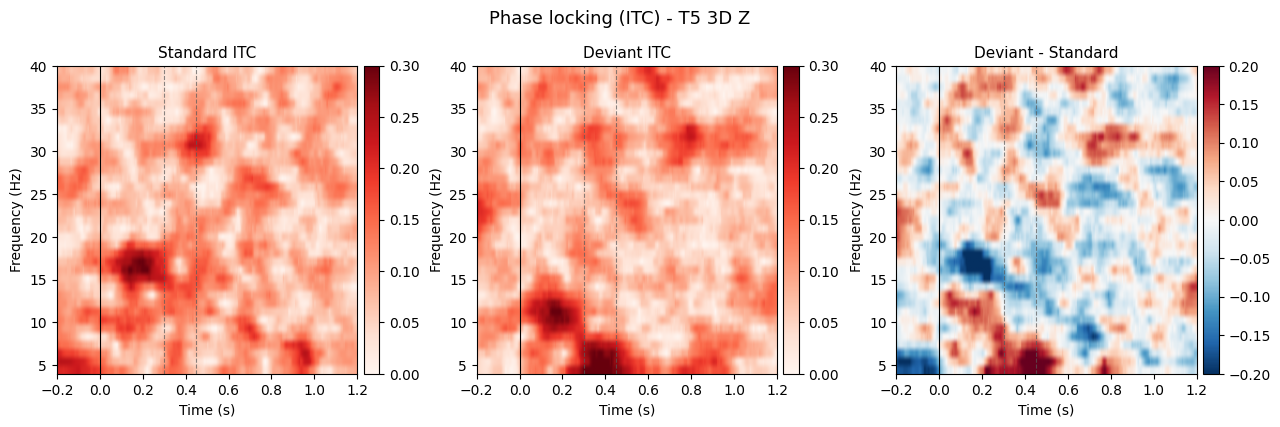

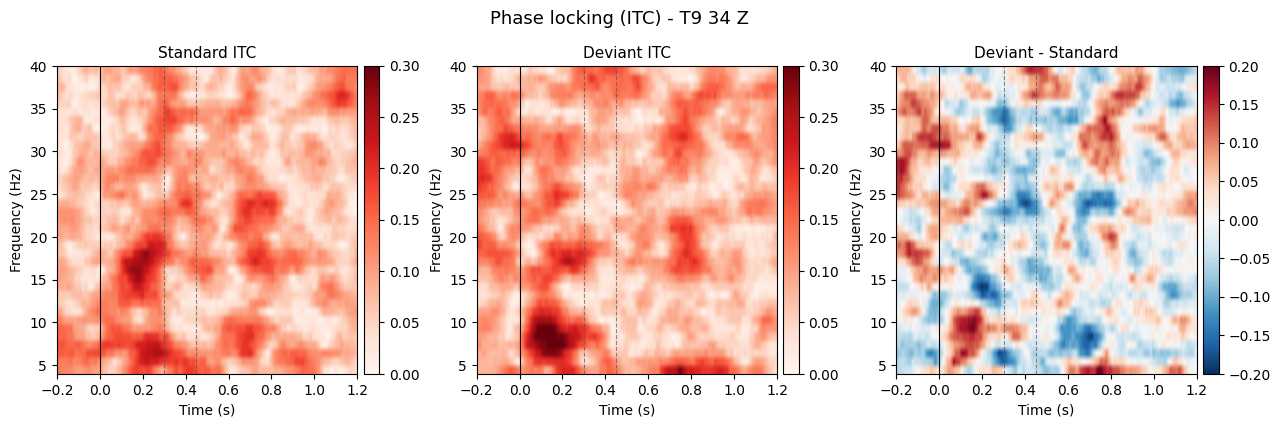

In [23]:
WINDOW_MS = (300, 450)        # team consensus window
THETA_HZ  = (4, 8)            # theta band where the N400m sits


def plot_channel_itc(channel, itc_std, itc_dev, itc_diff, window_ms=WINDOW_MS):
    """Three-panel ITC figure for one channel — clean version (no black box)."""
    ch_idx = itc_std.ch_names.index(channel)
    times  = itc_std.times
    freqs_ = itc_std.freqs

    fig, axes = plt.subplots(1, 3, figsize=(15, 4),
                             gridspec_kw={'wspace': 0.30})
    panels = [
        ('Standard ITC',        itc_std.data[ch_idx],  'Reds',     (0, 0.30)),
        ('Deviant ITC',         itc_dev.data[ch_idx],  'Reds',     (0, 0.30)),
        ('Deviant - Standard',  itc_diff.data[ch_idx], 'RdBu_r',   (-0.20, 0.20)),
    ]
    for ax, (title, data, cmap, (vmin, vmax)) in zip(axes, panels):
        im = ax.imshow(
            data,
            aspect='auto', origin='lower',
            extent=[times[0], times[-1], freqs_[0], freqs_[-1]],
            cmap=cmap, vmin=vmin, vmax=vmax,
        )
        # Subtle window markers — thin grey dashed verticals at 300 and 450 ms.
        # No theta-band rectangle: it cluttered the figure and the test is
        # described in the caption.
        for ms in window_ms:
            ax.axvline(ms / 1000, color='0.35', lw=0.8, ls='--', alpha=0.7)
        ax.axvline(0, color='black', lw=0.8)  # word onset
        ax.set_title(title, fontsize=11)
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Frequency (Hz)')
        plt.colorbar(im, ax=ax, fraction=0.05, pad=0.02)

    fig.suptitle(f'Phase locking (ITC) - {channel}', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


for ch in CHANS_OF_INTEREST:
    plot_channel_itc(ch, itc_std, itc_dev, itc_diff)


In [25]:
def box_mean(itc_obj, ch, window_ms=WINDOW_MS, freq_band=THETA_HZ):
    """Mean ITC in time × frequency box for one channel."""
    ch_idx = itc_obj.ch_names.index(ch)
    t_mask = (itc_obj.times >= window_ms[0]/1000) & (itc_obj.times <= window_ms[1]/1000)
    f_mask = (itc_obj.freqs >= freq_band[0]) & (itc_obj.freqs <= freq_band[1])
    return itc_obj.data[ch_idx][np.ix_(f_mask, t_mask)].mean()

print(f'Mean ITC in {WINDOW_MS[0]}-{WINDOW_MS[1]} ms × {THETA_HZ[0]}-{THETA_HZ[1]} Hz box:')
print()
print(f'  {"Channel":<12}{"Standard":>10}{"Deviant":>10}{"Difference":>14}')
print(f'  {"-"*12}{"-"*10}{"-"*10}{"-"*14}')
for ch in CHANS_OF_INTEREST:
    s = box_mean(itc_std,  ch)
    d = box_mean(itc_dev,  ch)
    diff = d - s
    print(f'  {ch:<12}{s:>10.4f}{d:>10.4f}{diff:>+14.4f}')


Mean ITC in 300-450 ms × 4-8 Hz box:

  Channel       Standard   Deviant    Difference
  ----------------------------------------------
  T5 3D Z         0.1132    0.2610       +0.1478
  T9 34 Z         0.1418    0.1097       -0.0321


In [27]:
from mne.time_frequency import tfr_array_morlet

N_PERM = 500
RNG    = np.random.default_rng(42)

def itc_box_diff_for_shuffle(data_std, data_dev, sfreq, freqs_, n_cycles_,
                             times_, ch_idx, window_s, freq_band):
    """Compute (dev box mean) − (std box mean) ITC after the given trial split."""
    # Concatenate so we can shuffle along trial axis
    data_all = np.concatenate([data_std, data_dev], axis=0)
    n_std    = data_std.shape[0]

    # Split back (this function is called both for true labels and shuffled)
    grp_std = data_all[:n_std]
    grp_dev = data_all[n_std:]

    # Compute Morlet TFR → average ITC across trials
    # Output shape: (n_epochs, n_channels, n_freqs, n_times)
    def _itc(arr):
        # tfr_array_morlet supports output='complex' which we need for ITC
        out = tfr_array_morlet(
            arr, sfreq=sfreq, freqs=freqs_, n_cycles=n_cycles_,
            output='complex', verbose=False, n_jobs=1,
        )
        # ITC = |mean across trials of (X / |X|)|
        # out shape: (epochs, chs, freqs, times) for complex output (no taper axis here)
        norm = out / np.abs(out)
        itc  = np.abs(norm.mean(axis=0))      # → (chs, freqs, times)
        return itc

    itc_s = _itc(grp_std)
    itc_d = _itc(grp_dev)

    # Box mean
    t_mask = (times_ >= window_s[0]) & (times_ <= window_s[1])
    f_mask = (freqs_ >= freq_band[0]) & (freqs_ <= freq_band[1])
    s_box = itc_s[ch_idx][np.ix_(f_mask, t_mask)].mean()
    d_box = itc_d[ch_idx][np.ix_(f_mask, t_mask)].mean()
    return d_box - s_box


# Pre-pull the raw epoch data ONCE for the two channels — much faster
def perm_test_for_channel(ch):
    ch_idx_z = epochs_z.ch_names.index(ch)
    sfreq    = epochs_z.info['sfreq']

    # Pull data for ONLY this one channel to keep memory low and speed up
    # data shape: (n_trials, 1, n_times) — we slice channel here
    data_std_full = epochs_std_matched.get_data(picks=[ch])  # (n_std, 1, n_times)
    data_dev_full = epochs_dev_matched.get_data(picks=[ch])

    # We need the time vector that tfr_array_morlet would use (no decim here for simplicity).
    times_   = epochs_z.times
    freqs_   = freqs
    n_cyc_   = n_cycles
    window_s = (WINDOW_MS[0]/1000, WINDOW_MS[1]/1000)
    band     = THETA_HZ

    # ── Real difference ────────────────────────────────────────────────────
    real_diff = itc_box_diff_for_shuffle(
        data_std_full, data_dev_full, sfreq, freqs_, n_cyc_,
        times_, ch_idx=0, window_s=window_s, freq_band=band,
    )

    # ── Permutations ──────────────────────────────────────────────────────
    n_std = data_std_full.shape[0]
    n_dev = data_dev_full.shape[0]
    all_data = np.concatenate([data_std_full, data_dev_full], axis=0)
    n_total  = n_std + n_dev

    null_diffs = np.zeros(N_PERM)
    for p in range(N_PERM):
        perm_idx = RNG.permutation(n_total)
        shuf_std = all_data[perm_idx[:n_std]]
        shuf_dev = all_data[perm_idx[n_std:]]
        null_diffs[p] = itc_box_diff_for_shuffle(
            shuf_std, shuf_dev, sfreq, freqs_, n_cyc_,
            times_, ch_idx=0, window_s=window_s, freq_band=band,
        )
        if (p + 1) % 100 == 0:
            print(f'    {ch}: permutation {p+1}/{N_PERM} done')

    p_val = (np.sum(null_diffs >= real_diff) + 1) / (N_PERM + 1)
    return real_diff, null_diffs, p_val


results = {}
for ch in CHANS_OF_INTEREST:
    print(f'\nPermutation test — {ch}')
    real_diff, null_diffs, p_val = perm_test_for_channel(ch)
    results[ch] = dict(real=real_diff, null=null_diffs, p=p_val)
    print(f'  Real ITC difference (deviant − standard) : {real_diff:+.4f}')
    print(f'  Null mean ± std                          : {null_diffs.mean():+.4f} ± {null_diffs.std():.4f}')
    print(f'  One-sided p-value                        : {p_val:.4f}')



Permutation test — T5 3D Z
    T5 3D Z: permutation 100/500 done
    T5 3D Z: permutation 200/500 done
    T5 3D Z: permutation 300/500 done
    T5 3D Z: permutation 400/500 done
    T5 3D Z: permutation 500/500 done
  Real ITC difference (deviant − standard) : +0.1476
  Null mean ± std                          : -0.0000 ± 0.0622
  One-sided p-value                        : 0.0100

Permutation test — T9 34 Z
    T9 34 Z: permutation 100/500 done
    T9 34 Z: permutation 200/500 done
    T9 34 Z: permutation 300/500 done
    T9 34 Z: permutation 400/500 done
    T9 34 Z: permutation 500/500 done
  Real ITC difference (deviant − standard) : -0.0317
  Null mean ± std                          : +0.0020 ± 0.0495
  One-sided p-value                        : 0.7605


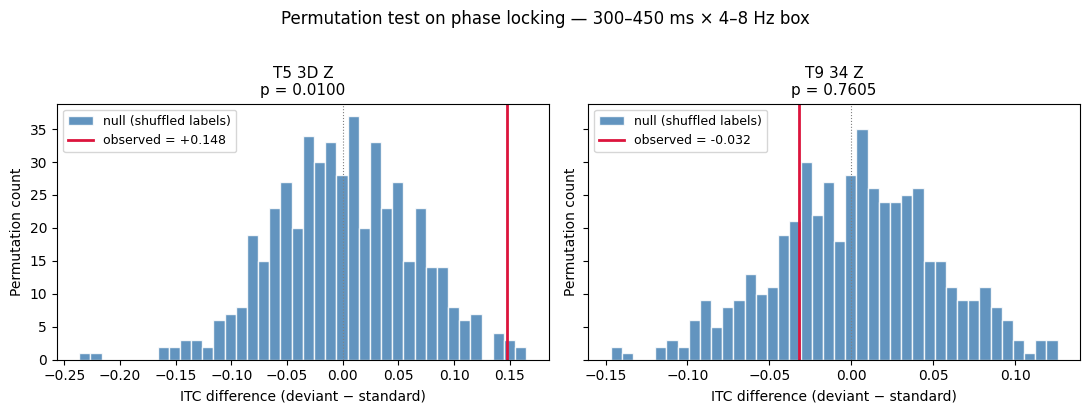

In [28]:
fig, axes = plt.subplots(1, len(CHANS_OF_INTEREST),
                         figsize=(5.5 * len(CHANS_OF_INTEREST), 4.0),
                         sharey=True)
if len(CHANS_OF_INTEREST) == 1:
    axes = [axes]

for ax, ch in zip(axes, CHANS_OF_INTEREST):
    r = results[ch]
    ax.hist(r['null'], bins=40, color='steelblue', edgecolor='white',
            alpha=0.85, label='null (shuffled labels)')
    ax.axvline(r['real'], color='crimson', lw=2, label=f'observed = {r["real"]:+.3f}')
    ax.axvline(0, color='grey', lw=0.8, ls=':')
    ax.set_title(f'{ch}\np = {r["p"]:.4f}', fontsize=11)
    ax.set_xlabel('ITC difference (deviant − standard)')
    ax.set_ylabel('Permutation count')
    ax.legend(fontsize=9, loc='upper left')

fig.suptitle(
    f'Permutation test on phase locking — '
    f'{WINDOW_MS[0]}–{WINDOW_MS[1]} ms × {THETA_HZ[0]}–{THETA_HZ[1]} Hz box',
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.show()
